FTT example

Example from: https://docs.scipy.org/doc/scipy/reference/tutorial/fft.html

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.fftpack
import os
import csv

y shape: (600,)
yf shape: (600,)


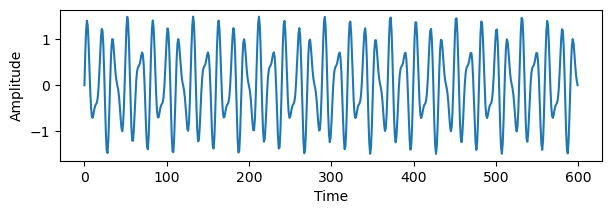

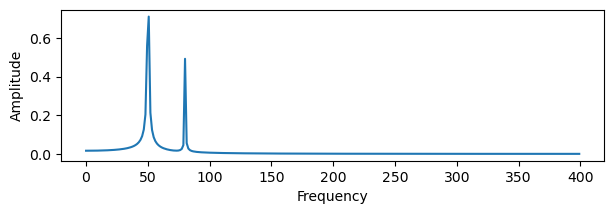

In [164]:
# Number of sample points
N = 600
# sample spacing
T = 1.0 / 800.0
x = np.linspace(0.0, N*T, N)
y = np.sin(50.0 * 2.0*np.pi*x) + 0.5*np.sin(80.0 * 2.0*np.pi*x)
print('y shape: '+str(y.shape))
yf = scipy.fftpack.fft(y)
#It gives the real and the imaginary values, so we use the (abs) to get the real ones
xf = np.linspace(0.0, 1.0//(2.0*T), N//2)
y_axis=2.0/N * np.abs(yf[:N//2])
print('yf shape: '+str(yf.shape))
plt.figure(figsize=(7,2), dpi=100)
plt.plot(y)
plt.ylabel('Amplitude')
plt.xlabel('Time')
plt.show()
fig, ax = plt.subplots(figsize=(7,2), dpi=100)
ax.plot(xf, 2.0/N * np.abs(yf[:N//2]))
plt.ylabel('Amplitude')
plt.xlabel('Frequency')
plt.show()

FTT With Lukas on my Kymograph Data

We used the hanning algorithm to avoid border effects of the FT.
https://www.cbcity.de/die-fft-mit-python-einfach-erklaert

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.fftpack

csv_filepath='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_10-50-18_control_worm2_spline_K.csv'
K = np.genfromtxt(csv_filepath, delimiter=',')
#to remove nan rows in the data
K=K[~np.isnan(K).any(axis=1)]

### Show different segments

(100, 198248)


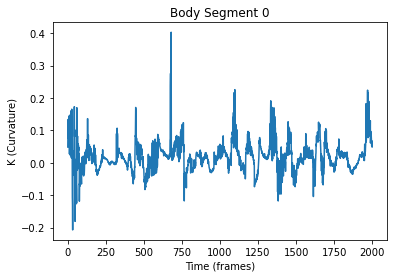

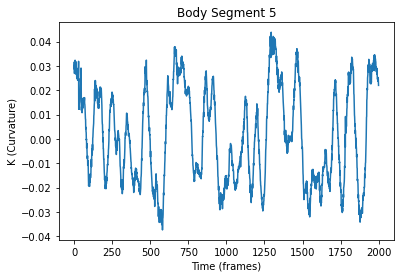

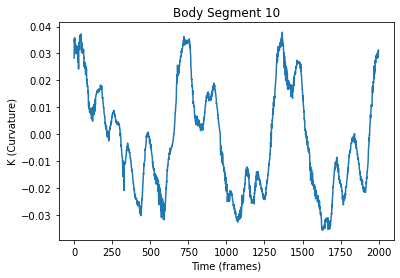

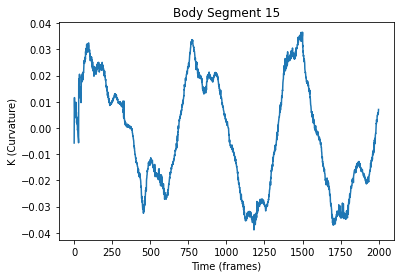

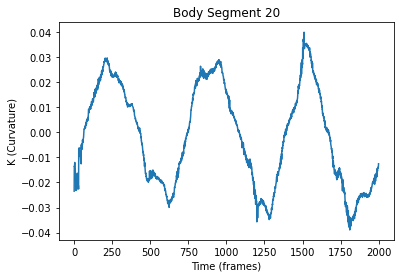

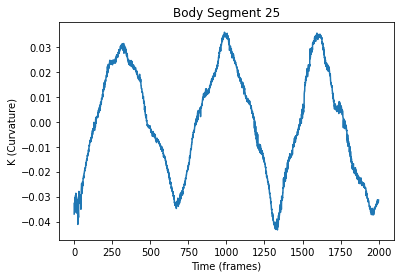

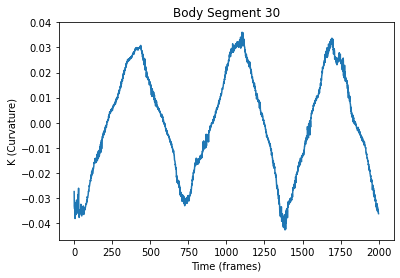

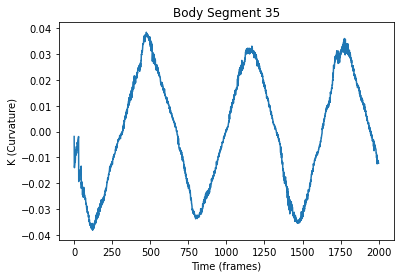

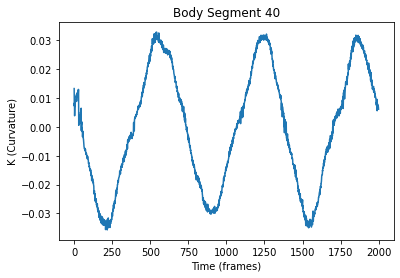

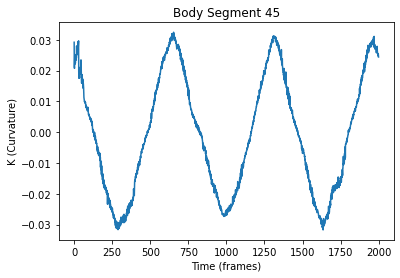

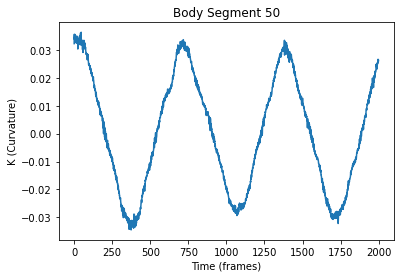

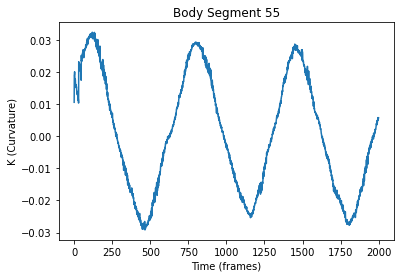

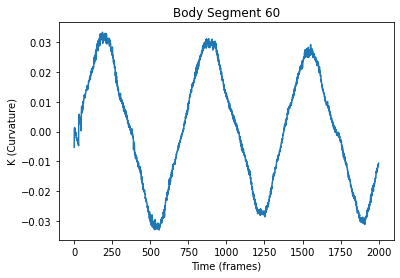

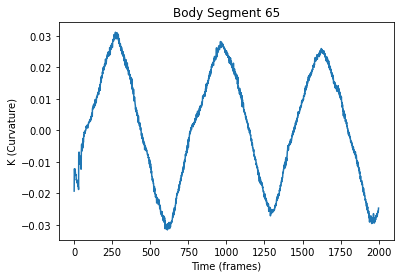

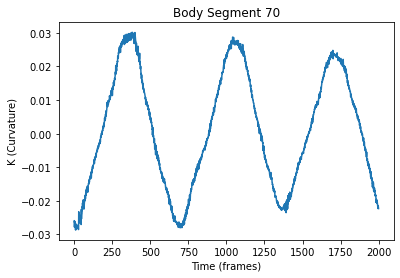

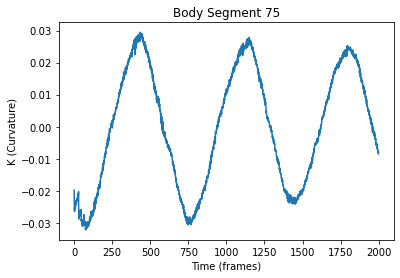

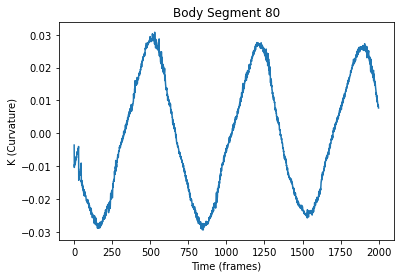

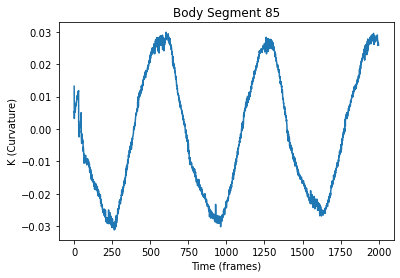

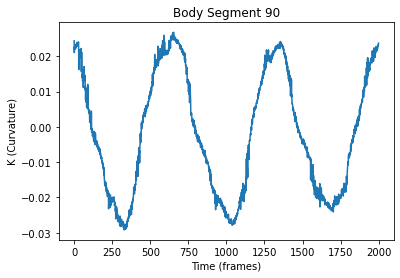

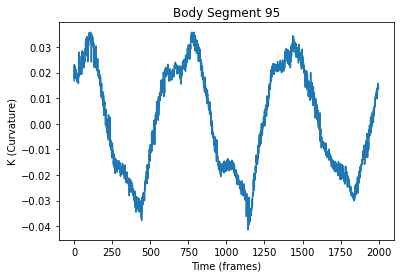

In [179]:
Kt=K.T
print(Kt.shape)
for idx, segment in enumerate(Kt):
    if idx%5!=0: continue
    #plt.figure(dpi=100)
    plt.plot(segment[0:2000])
    plt.title('Body Segment '+str(idx))
    plt.xlabel('Time (frames)')
    plt.ylabel('K (Curvature)')
    plt.show()
#    break

Text(0.5, 0, 'Frequency (Hz)')

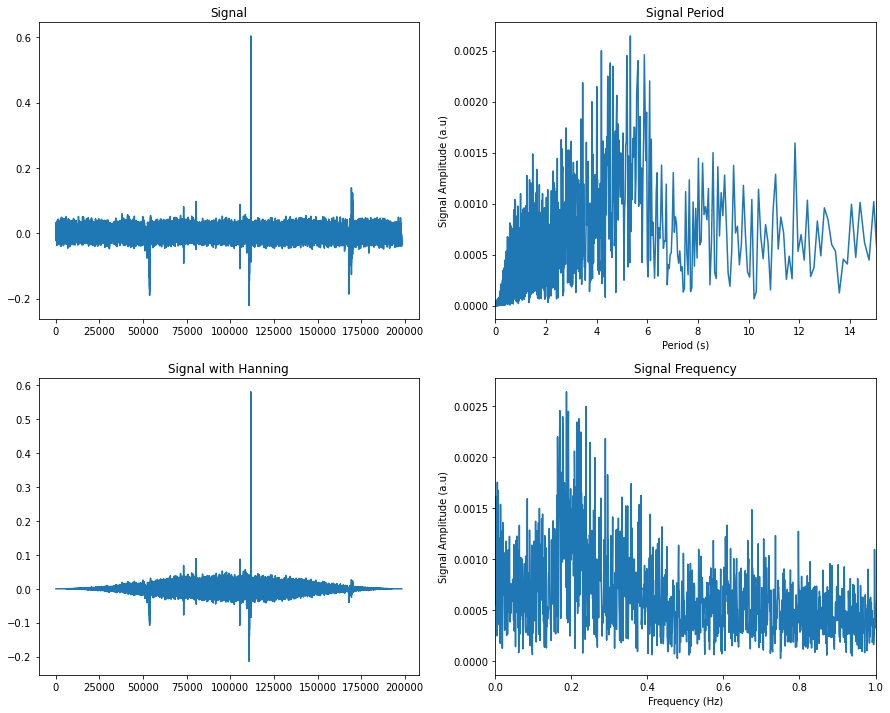

In [223]:
#number of sample points with Hanning
y=K[:,5]
N=len(y) #this might be wrong
hann=np.hanning(N)
#sample spacing
T=1.0/167.0
x=np.linspace(0.0, N*T, N)
yf=scipy.fftpack.fft(y)#*hann)

xf=np.linspace(0.0, 1.0//(2.0*T), N//2)
#xf=scipy.fftpack.fftfreq(N,T)
y_axis=2.0/N * np.abs(yf[:N//2])

plt.figure(figsize=(15,12))
plt.subplot(2,2,1)
plt.plot(y)
plt.title('Signal')
plt.subplot(2,2,3)
plt.plot(y*hann)
plt.title('Signal with Hanning')
plt.subplot(2,2,2)
plt.plot(1/xf[1:N//2], 2.0/N * np.abs(yf[1:N//2]))
#plt.xlim(0,max(xf[1:N//2]))
plt.xlim(0,15)
plt.title('Signal Period')
plt.xlabel('Period (s)')
plt.ylabel('Signal Amplitude (a.u)')
plt.subplot(2,2,4)
plt.plot(xf[1:N//2], 2.0/N * np.abs(yf[1:N//2]))
plt.xlim(0,max(xf[1:N//2]))
plt.xlim(0,1)
plt.title('Signal Frequency')
plt.ylabel('Signal Amplitude (a.u)')
plt.xlabel('Frequency (Hz)')

### Comparison of x axis

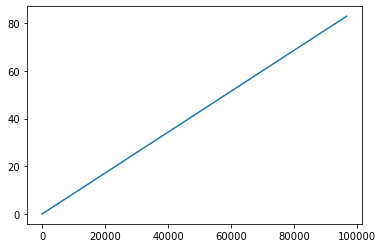

In [31]:
plt.plot(xf[1:N//2])


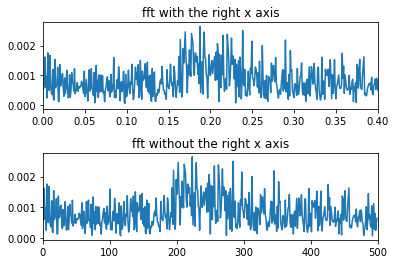

In [131]:
plt.subplot(2,1,1)
plt.plot(xf[1:N//2], 2.0/N * np.abs(yf[1:N//2]))
plt.xlim(0,0.4)
plt.title('fft with the right x axis')
plt.subplot(2,1,2)
plt.plot((2.0/N * np.abs(yf[1:N//2]))[0:500])
plt.xlim(0,500)
plt.title('fft without the right x axis')
plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.5)
plt.show()

In [ ]:
# Let's do it for the whole splineK and save it an image

In [5]:
csv_filepath='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_good_skeleton/2020-07-01_16-20-36_chemotaxisl_worm5_spline_K.csv'
K = np.genfromtxt(csv_filepath, delimiter=',')
#to remove nan rows in the data
K=K[~np.isnan(K).any(axis=1)]
Kt=K.T

In [6]:
N=Kts.shape[1]
print(N)

193372


In [32]:
xf.shape

(96686,)

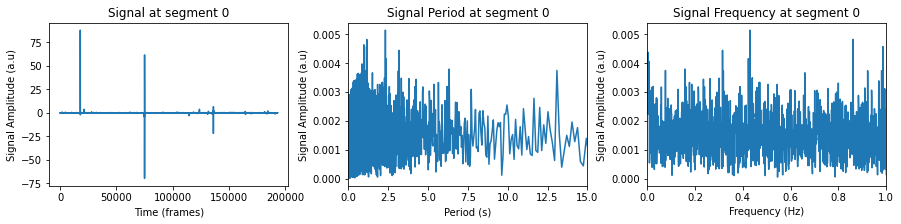

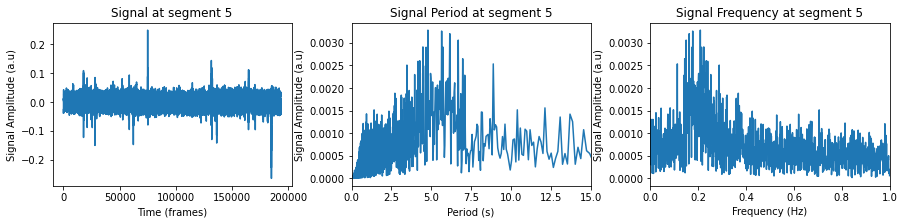

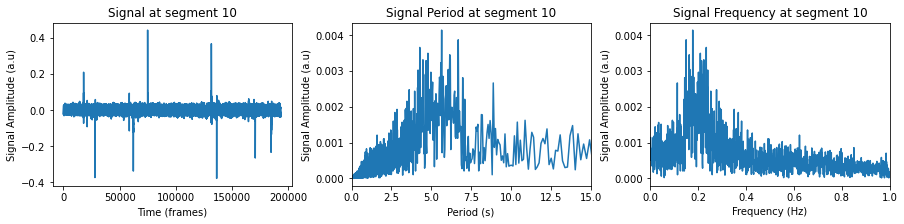

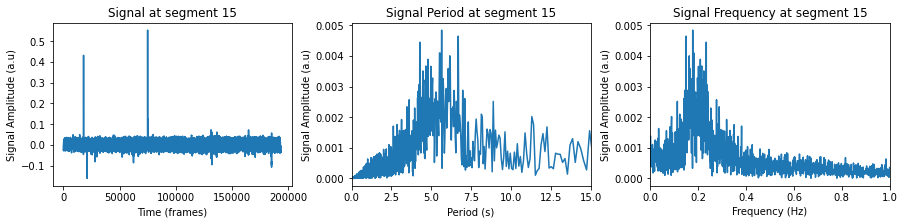

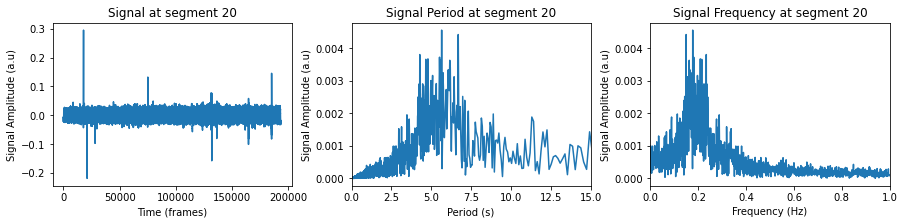

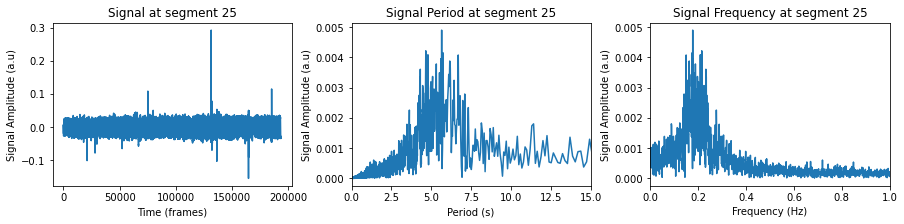

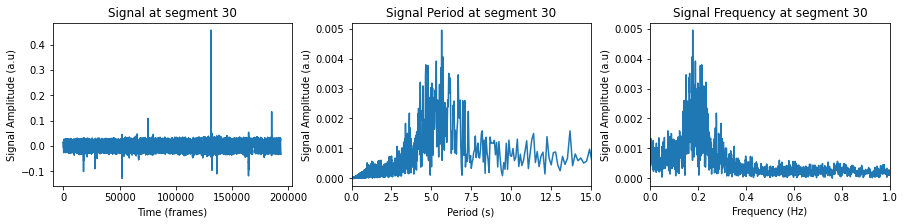

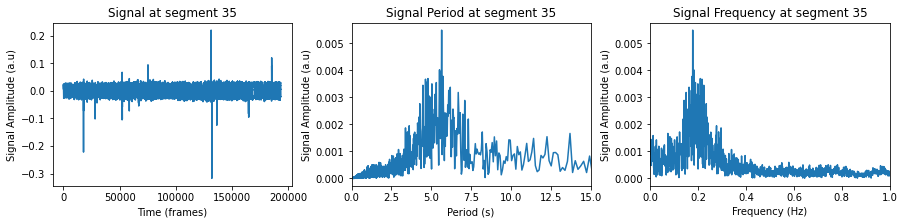

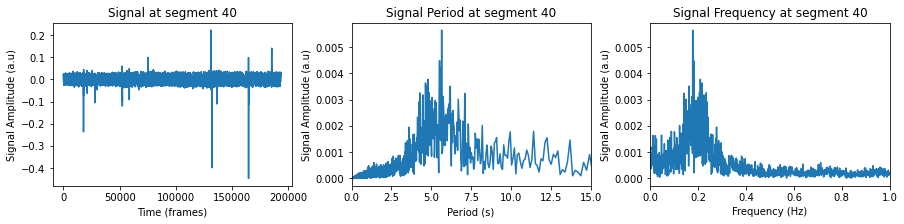

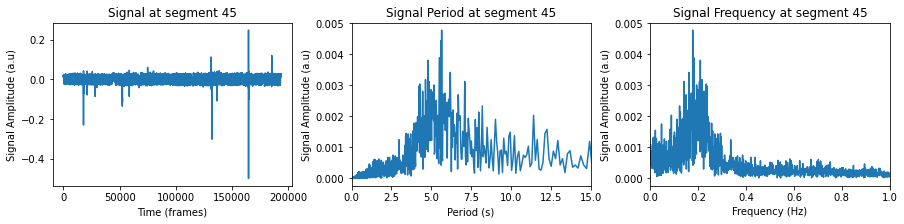

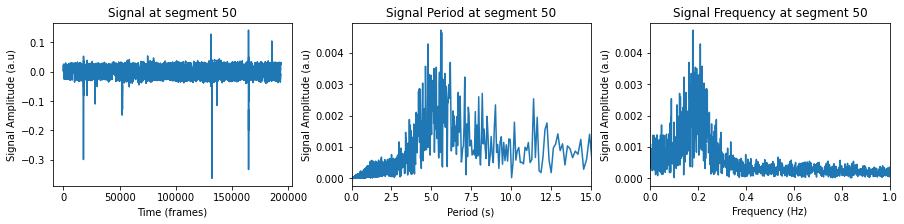

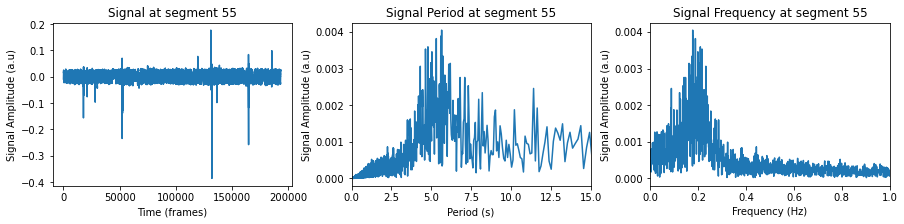

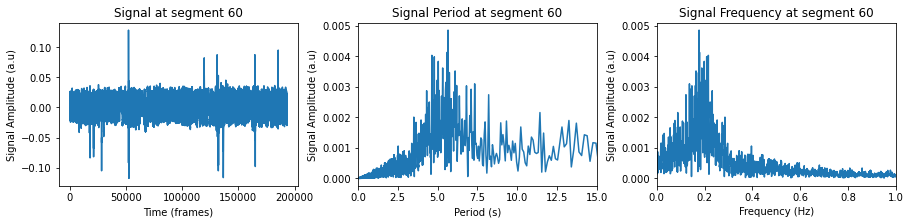

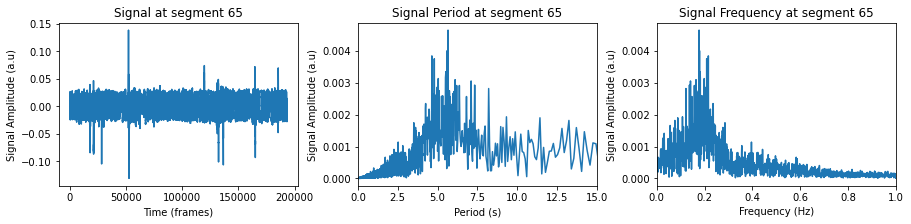

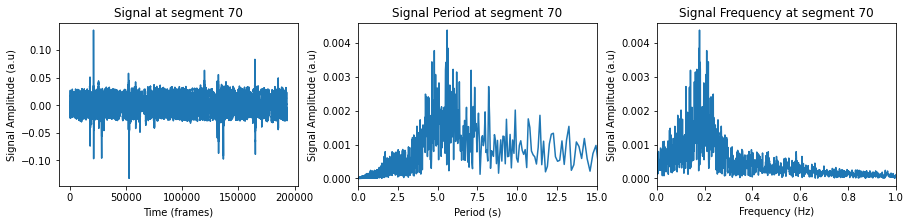

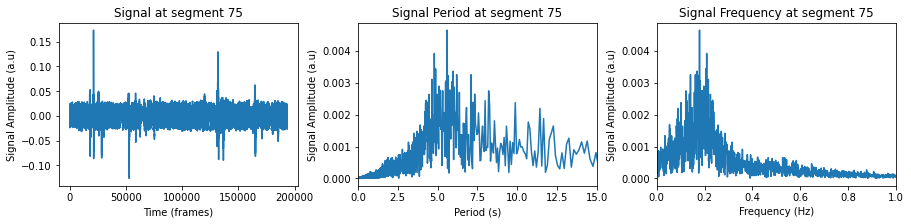

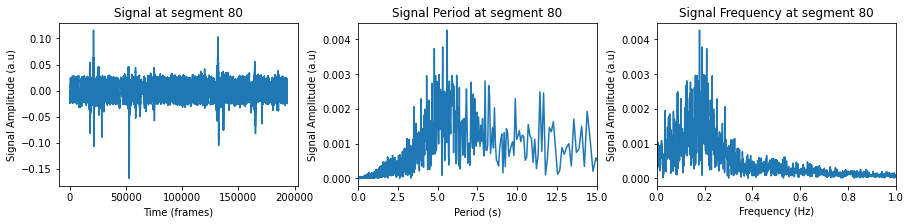

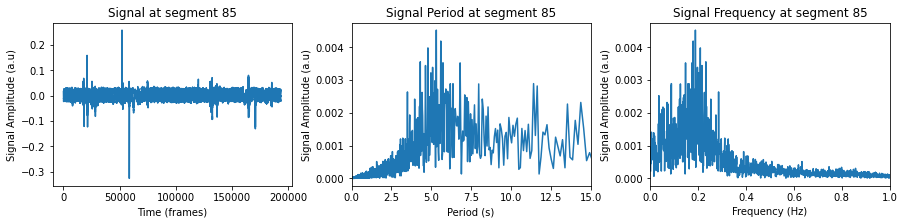

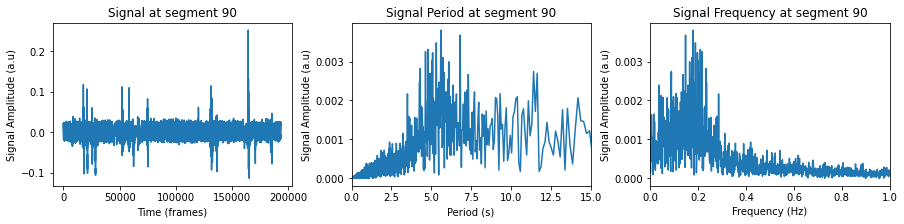

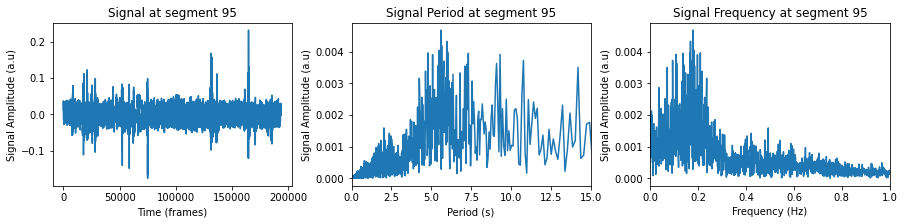

In [23]:
plt.rcParams.update({'figure.max_open_warning': 0})
#number of sample points
#Kts= Kt short

Kts=Kt#[:,79640:130700]


N=Kts.shape[1]

#hanning
hann=np.hanning(N)

#sample spacing
T=1.0/167.0
x=np.linspace(0.0, N*T, N)


xf=np.linspace(0.0, 1.0//(2.0*T), N//2)
#xf=scipy.fftpack.fftfreq(N,T)


output_path='/groups/zimmer/Ulises/wbfm/chemotaxis_assay/2020_Only_behaviour/all_fourier/'
fourierMap=open(os.path.join(output_path,'2020-07-01_16-20-36_chemotaxisl_worm5_fourierMap.csv'),'w', newline='')
csv_writerfourierMap=csv.writer(fourierMap)

fourierSpectrum=np.empty(shape=(xf.shape))

for idx, segment in enumerate(Kts):
    #if idx%5!=0:continue
    y=segment
    yf=scipy.fftpack.fft(y)#*hann)
    #y axis
    y_axis=2.0/N * np.abs(yf[:N//2])
    #writer:
    #csv_writerfourierMap.writerow(2.0/N * np.abs(yf[1:N//2]))
    #plotting:
    plotting=1
    if plotting==0:continue
    plt.figure(figsize=(15,3))
    plt.subplot(1,3,1)
    plt.plot(y)
    plt.title('Signal at segment '+str(idx))
    plt.xlabel('Time (frames)')
    plt.ylabel('Signal Amplitude (a.u)')
    
    plt.subplot(1,3,2)
    plt.plot(1/xf[1:N//2], 2.0/N * np.abs(yf[1:N//2]))
    plt.xlim(0,15)
    plt.title('Signal Period at segment '+str(idx))
    plt.xlabel('Period (s)')
    plt.ylabel('Signal Amplitude (a.u)')
    
    plt.subplot(1,3,3)
    plt.plot(xf[1:N//2], 2.0/N * np.abs(yf[1:N//2]))
    plt.xlim(0,max(xf[1:N//2]))
    plt.xlim(0,1)
    plt.title('Signal Frequency at segment '+str(idx))
    plt.ylabel('Signal Amplitude (a.u)')
    plt.xlabel('Frequency (Hz)')
    
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.25, hspace=0.25)

fourierMap.close()

(5000,)

In [8]:
import pandas
df=pd.read_csv(os.path.join(output_path,'2020-07-01_16-20-36_chemotaxisl_worm5_fourierMap.csv'), header=None)
df.shape

(100, 96685)

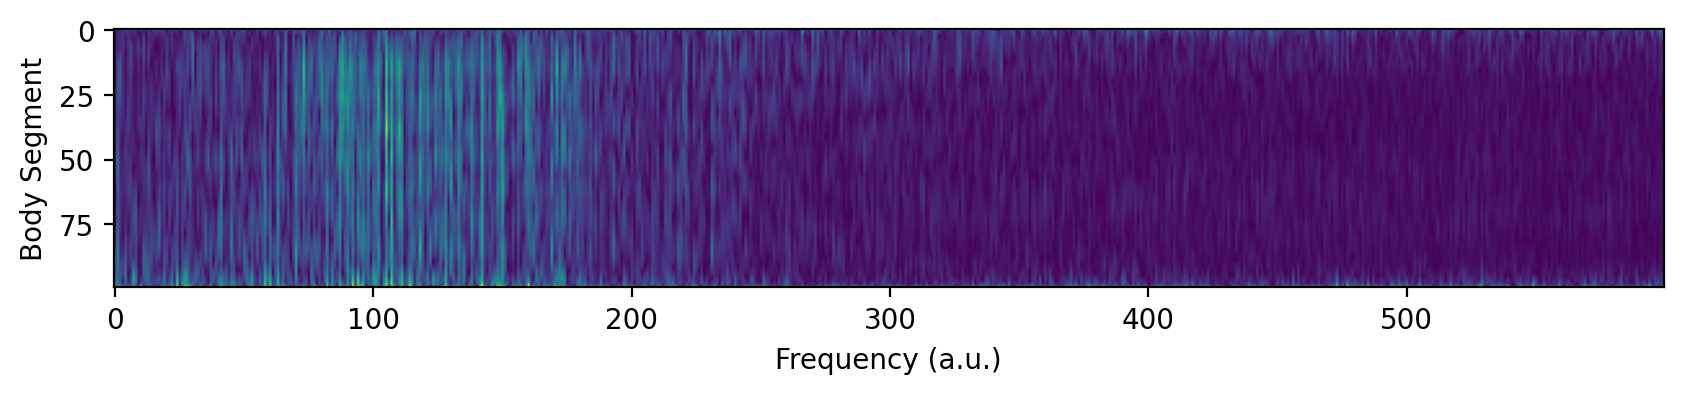

In [9]:
plt.figure(figsize=(10,5),dpi=200)
#plt.imshow(df.iloc[:,:40])
plt.imshow(df.iloc[:,100:700])
plt.xlabel('Frequency (a.u.)')
plt.ylabel('Body Segment')
plt.savefig(output_path+'2020-07-01_16-20-36_chemotaxisl_worm5_fourierMap.tiff',dpi=400)